=============================   GPU Information  ================================
Device 1 of 1:		NVIDIA GeForce RTX 5060 Ti
Compute Capability:	12.0
Global Memory:		17102864384 B
Constant Memory:	65536 B
Shared Memory:		49152 B
Registers:		65536
Clock Speed:		2.62 GHz
Number of SMs:		36
Number of Cores:	4608
Auto-thread:		147456
Auto-block:		64
nphoton: 1e+07
tstart: 0
tstep: 5e-09
tend: 5e-09
isreflect: 0
issrcfrom0: 1


###############################################################################
#                      Monte Carlo eXtreme (MCX) -- CUDA                      #
#          Copyright (c) 2009-2025 Qianqian Fang <q.fang at neu.edu>          #
#                https://mcx.space/  &  https://neurojson.io                  #
#                                                                             #
# Computational Optics & Translational Imaging (COTI) Lab- http://fanglab.org #
#   Department of Bioengineering, Northeastern University, Boston, MA, USA    #
###############################################################################
#    The MCX Project is funded by the NIH/NIGMS under grant R01-GM114365      #
###############################################################################
#  Open-source codes and reusable scientific data are essential for research, #
# MCX proudly developed human-readable JSON-based data formats for easy reuse.#
#                                       

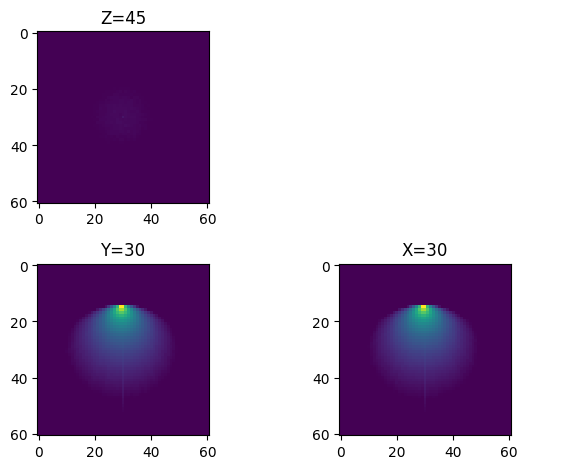

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pmcx

gpus = pmcx.gpuinfo()
gpus[0]

# Method 1, setup simulation
cfg = {}
cfg["nphoton"] = 1e7
cfg["vol"] = np.ones([61, 61, 61], dtype="uint8")
cfg["srcpos"] = [30, 30, 15]
cfg["srcdir"] = [0, 0, 1, 1]
cfg["prop"] = [[0, 0, 1, 1], [0.001, 0, 1, 1]]
cfg["tstart"] = 0
cfg["tend"] = 5e-9
cfg["tstep"] = 5e-9
cfg["isreflect"] = 0
cfg["issrcfrom0"] = 1

theta_min = 0
theta_max = np.pi / 2
probabilities = np.linspace(np.cos(theta_min), np.cos(theta_max), 3)
theta_values = np.arccos(probabilities)
normalized_theta_values = theta_values / np.pi

cfg["angleinvcdf"] = pd.read_csv("angleinvcdf.csv")["angleinvcdf"].to_numpy().tolist()

# Run the simulation
res = pmcx.run(cfg)

# plot every point with negligable offset
res["flux"] = res["flux"] + 1e-40

# plot cross sections
fig = plt.figure()
gs = fig.add_gridspec(2, 2)
(ax1, ax2), (ax3, ax4) = gs.subplots()
vmin = np.log10(res["flux"].max()) - 3
vmax = np.log10(res["flux"].max())
ax1.imshow(np.log10(res["flux"][:, :, 45]), interpolation="nearest", vmin=vmin, vmax=vmax)
ax1.set_title("Z=45")
ax2.set_axis_off()
ax3.imshow(
    np.log10(np.squeeze(res["flux"][:, 30, :])).T, interpolation="nearest", vmin=vmin, vmax=vmax
)
ax3.set_title("Y=30")
ax4.imshow(
    np.log10(np.squeeze(res["flux"][30, :, :])).T, interpolation="nearest", vmin=vmin, vmax=vmax
)
ax4.set_title("X=30")

plt.tight_layout()
plt.show()
